In [1]:
import os, copy, time
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndimg
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.models import resnet152, ResNet152_Weights
import time, copy

In [ ]:
from torchvision import transforms

transformers = {
    'train_transforms': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((150,150)),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]),

    'valid_transforms': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((150,150)),
        transforms.ToTensor()
    ]),

    'test_transforms': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((150,150)),
        transforms.ToTensor()
    ])
}

trans = ['train_transforms', 'valid_transforms', 'test_transforms']

path = "data/raw/chest_xray/chest_xray"

categories = ['train', 'val', 'test']

In [3]:
dset = {
    x: torchvision.datasets.ImageFolder(os.path.join(path, x),
                                        transform=transformers[y])
    for x, y in zip(categories, trans)
}

dataset_sizes = {x: len(dset[x]) for x in categories}
class_names = dset['train'].classes

dataloaders = {
    x: torch.utils.data.DataLoader(dset[x], batch_size=32, shuffle=True, num_workers=4)
    for x in categories
}

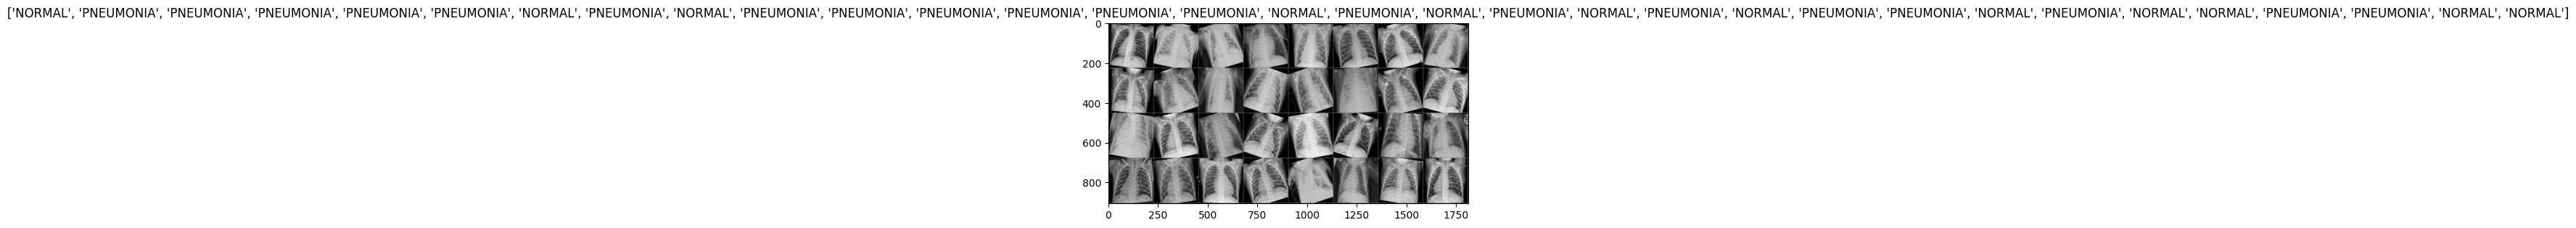

In [4]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders["train"]))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [5]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.DEFAULT)

        # Freeze layers
        for params in self.model.parameters():
            params.requires_grad = False

        # Replace classifier
        self.classifier = nn.Sequential(
            nn.Linear(self.model.fc.in_features, 2),
            nn.LogSoftmax(dim=1)
        )
        self.model.fc = self.classifier

    def forward(self, x):
        return self.model(x)

    def fit(self, dataloaders, num_epochs=10):
        train_on_gpu = torch.cuda.is_available()
        optimizer = optim.Adam(self.model.fc.parameters(), lr=0.001)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)
        criterion = nn.NLLLoss()

        since = time.time()
        best_model_wts = copy.deepcopy(self.model.state_dict())
        best_acc = 0.0

        if train_on_gpu:
            self.model = self.model.cuda()

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    self.model.train()
                else:
                    self.model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    if train_on_gpu:
                        inputs, labels = inputs.cuda(), labels.cuda()

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = self.model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # ✅ Automatically get dataset size
                epoch_loss = running_loss / len(dataloaders[phase].dataset)
                epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(self.model.state_dict())

            scheduler.step()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

        self.model.load_state_dict(best_model_wts)
        return self.model


In [6]:
# Example usage
model = Model()
model_ft = model.fit(dataloaders, num_epochs=11)
torch.save(model_ft.state_dict(), "pneumonia_resnet152.pth")
print("Model saved!")

Epoch 0/10
----------
train Loss: 0.2956 Acc: 0.8794
val Loss: 0.4346 Acc: 0.6875
Epoch 1/10
----------
train Loss: 0.1829 Acc: 0.9325
val Loss: 0.4858 Acc: 0.6875
Epoch 2/10
----------
train Loss: 0.1586 Acc: 0.9411
val Loss: 0.5837 Acc: 0.6875
Epoch 3/10
----------
train Loss: 0.1416 Acc: 0.9457
val Loss: 0.7196 Acc: 0.6250
Epoch 4/10
----------
train Loss: 0.1358 Acc: 0.9540
val Loss: 0.6268 Acc: 0.6875
Epoch 5/10
----------
train Loss: 0.1368 Acc: 0.9496
val Loss: 0.5896 Acc: 0.6875
Epoch 6/10
----------
train Loss: 0.1361 Acc: 0.9488
val Loss: 0.5750 Acc: 0.6875
Epoch 7/10
----------
train Loss: 0.1340 Acc: 0.9534
val Loss: 0.5641 Acc: 0.6875
Epoch 8/10
----------
train Loss: 0.1314 Acc: 0.9521
val Loss: 0.5906 Acc: 0.6875
Epoch 9/10
----------
train Loss: 0.1345 Acc: 0.9513
val Loss: 0.5504 Acc: 0.6875
Epoch 10/10
----------
train Loss: 0.1345 Acc: 0.9486
val Loss: 0.5190 Acc: 0.6875
Training complete in 18m 56s
Best val Acc: 0.6875
Model saved!


In [7]:
class LayerActivations():
    def __init__(self, model):
        self.features = []
        self.hooks = []
        self.hooks.append(model.layer4.register_forward_hook(self.hook_fn))

    def hook_fn(self, module, input, output):
        self.features.append(output)

    def remove(self):
        for hook in self.hooks:
            hook.remove()

model_ft = model.model
acts = LayerActivations(model_ft)

In [8]:
loader = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def image_loader(image_name):
    image = Image.open(image_name).convert("RGB")
    image = loader(image).float()
    image = image.unsqueeze(0) 
    return image


In [9]:
image_path = 'IM-0001-0001.jpeg'
img = image_loader(image_path)
logps = model_ft(img.cuda() if torch.cuda.is_available() else img)

out_features = acts.features[0].squeeze(0)
out_features = np.transpose(out_features.cpu().detach(), (1, 2, 0))

# Forward pass
ps = torch.exp(logps)
pred = np.argmax(ps.cpu().detach())

# Get final layer weights for predicted class
W = model_ft.fc[0].weight
w = W[pred, :]

# ✅ Convert everything to numpy
out_features_np = out_features.detach().cpu().numpy()  # shape (7,7,2048)
w_np = w.detach().cpu().numpy()                        # shape (2048,)

# Dot product for class activation map
cam = np.dot(out_features_np, w_np)  # shape (7,7)

# Resize to 224x224
class_activation = ndimg.zoom(cam, zoom=(32, 32), order=1)

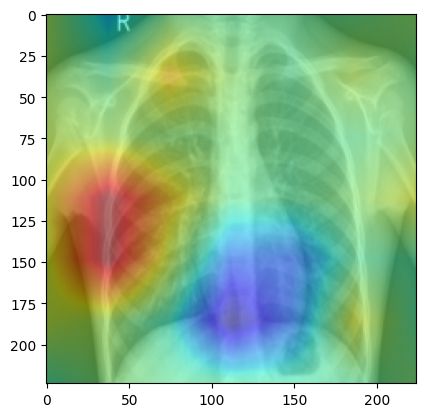

In [10]:
img_show = img.squeeze(0).cpu().numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_show = std * img_show + mean
img_show = np.clip(img_show, 0, 1)

plt.imshow(img_show, alpha=1)
plt.imshow(class_activation, cmap='jet', alpha=0.5)
plt.show()